In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/processed/week2_filtered.csv')
print(df.shape)  # sanity check — should be 71,466 rows × 79 cols

(71466, 79)


In [2]:
#Dropped columns that had above 95% of missing values - obtained from week 1 exploration
cols_to_drop = [
    'CoveredSpaces', 'MiddleOrJuniorSchoolDistrict', 'TaxYear',
    'ElementarySchoolDistrict', 'BusinessType', 'TaxAnnualAmount',
    'FireplacesTotal', 'AboveGradeFinishedArea',
    'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'BuilderName'
]
df = df.drop(columns=cols_to_drop)
print(df.shape)  # should be 71466 rows × 67 cols

(71466, 67)


In [3]:
before = len(df)

df = df[(df['LivingArea'] > 0) & 
        (df['BedroomsTotal'] > 0) & 
        (df['BathroomsTotalInteger'] > 0)]

print(f"Dropped {before - len(df)} rows")
print(df.shape)

Dropped 92 rows
(71374, 67)


In [4]:
missing_coords = df[df['Latitude'].isna() | df['Longitude'].isna()]
print(len(missing_coords))
missing_coords[['ListingId', 'City', 'PostalCode', 'Latitude', 'Longitude']]

9


,ListingId,City,PostalCode,Latitude,Longitude
9846,41119347,Oakley,94561,NaN,NaN
11104,ML82027216,Carmel,93923,NaN,NaN
37455,ML82035928,Carmel,93921,NaN,NaN
41840,ML82032365,Carmel,93921,NaN,NaN
53561,41125069,Manteca,95337,NaN,NaN
53869,260004259SD,La Jolla,92037,NaN,NaN
57992,41118653,Manteca,95337,NaN,NaN
62299,ML82042856,Carmel,93923,NaN,NaN
64468,ML82039007,Carmel,93923,NaN,NaN


In [5]:
before = len(df)

df = df.dropna(subset=['Latitude', 'Longitude'])

print(f"Dropped {before - len(df)} rows")
print(df.shape)

Dropped 9 rows
(71365, 67)


<Axes: >

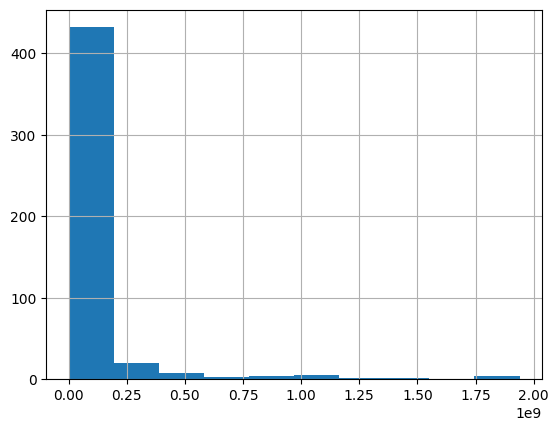

In [6]:
df[df['LotSizeSquareFeet'] > 435_600]['LotSizeSquareFeet'].hist()

In [7]:
df[df['LotSizeSquareFeet'] > 435_600]['LotSizeSquareFeet'].describe()

count    4.780000e+02
mean     6.849271e+07
std      2.483285e+08
min      4.360360e+05
25%      5.930694e+05
50%      9.143520e+05
75%      2.262398e+06
max      1.938943e+09
Name: LotSizeSquareFeet, dtype: float64

In [8]:
# --- LotSizeSquareFeet: outlier handling ---
# Week 2 found LotSizeSquareFeet max = 1.9 billion sqft, clearly a data error.
# First attempt: cap at 435,600 sqft (10 acres), assuming outliers were mostly bad data.
# But describe() on rows above that cap showed:
#   min=436K, 25%=593K, median=914K, 75%=2.26M, max=1.94B
# This means most of the 478 "outlier" rows are plausible large rural/ranch
# properties (CA does have legitimate 10-50+ acre residential lots, e.g. Central
# Valley, wine country). A fixed 10-acre cap would flatten real large properties
# down to the same value as a typo-driven 1.9B sqft row, destroying real signal.
#
# Better approach: cap only the extreme tail using a percentile-based threshold.
# This clips just the most implausible ~0.1% of rows (true data errors) while
# preserving the natural variation among genuinely large properties.

cap_999 = df['LotSizeSquareFeet'].quantile(0.999)
print(f"99.9th percentile cap: {cap_999}")

# Count how many rows are actually affected by this tighter, more honest cap
n_outliers = (df['LotSizeSquareFeet'] > cap_999).sum()
print(f"{n_outliers} rows above cap")

# Clip only the extreme tail — everything else (including large-but-real lots) is untouched
df['LotSizeSquareFeet'] = df['LotSizeSquareFeet'].clip(upper=cap_999)

99.9th percentile cap: 6969600.0
68 rows above cap


In [9]:
# --- LotSizeSquareFeet: missing values ---
# ~1.7% of rows are missing this field (per Week 2 missingness audit).
# Use median, not mean, since the distribution is heavily right-skewed —
# mean would be pulled upward by the large-lot properties and misrepresent
# a "typical" property.
median_lot = df['LotSizeSquareFeet'].median()
df['LotSizeSquareFeet'] = df['LotSizeSquareFeet'].fillna(median_lot)

print(f"Missing values remaining: {df['LotSizeSquareFeet'].isna().sum()}")  # should be 0

Missing values remaining: 0


In [10]:
df['GarageSpaces'].median()

np.float64(2.0)

In [11]:
df['GarageSpaces'].value_counts(dropna=False).sort_index()

GarageSpaces
0.0       5665
1.0       5791
1.5         22
2.0      44364
2.5         79
3.0      10957
3.5          7
4.0       1241
4.5          1
5.0        204
6.0        174
7.0         37
8.0         39
9.0          9
10.0        19
11.0         2
12.0         9
14.0         2
15.0         3
16.0         2
20.0         6
21.0         2
22.0         2
24.0         1
28.0         1
32.0         1
35.0         1
300.0        1
400.0        2
600.0        1
NaN       2720
Name: count, dtype: int64

In [12]:
# --- GarageSpaces: outlier check ---
# value_counts() reveals a small number of implausible values (300, 400, 600
# garage spaces) — clearly data entry errors, same pattern as LotSizeSquareFeet.
# Check how many rows are affected before deciding a cap.
print(df[df['GarageSpaces'] > 20]['GarageSpaces'].value_counts().sort_index())
print(f"\nRows with GarageSpaces > 20: {(df['GarageSpaces'] > 20).sum()}")

GarageSpaces
21.0     2
22.0     2
24.0     1
28.0     1
32.0     1
35.0     1
300.0    1
400.0    2
600.0    1
Name: count, dtype: int64

Rows with GarageSpaces > 20: 12


In [13]:
# --- GarageSpaces: outlier cap ---
# 12 rows have implausible values (21–600), almost certainly data entry errors
# (e.g. square footage typed into the wrong field). Unlike LotSizeSquareFeet,
# there's no plausible real-world scenario for a 300+ car residential garage,
# so a small fixed cap is safe here — no percentile analysis needed.
GARAGE_CAP = 10  # generous ceiling; even large estates rarely exceed this
n_outliers = (df['GarageSpaces'] > GARAGE_CAP).sum()
print(f"{n_outliers} rows above {GARAGE_CAP}")

df['GarageSpaces'] = df['GarageSpaces'].clip(upper=GARAGE_CAP)

# --- GarageSpaces: missing values ---
# ~3.8% missing. Median (2.0) would assert a specific garage count with no
# evidence. Distribution check shows 0 is a common, real value (~8% of rows),
# so filling missing with 0 is a conservative default that doesn't invent a
# garage that may not exist, rather than guessing at a "typical" one.
df['GarageSpaces'] = df['GarageSpaces'].fillna(0)

print(f"Missing values remaining: {df['GarageSpaces'].isna().sum()}")  # should be 0

36 rows above 10
Missing values remaining: 0


In [14]:
# --- YearBuilt: sanity check ---
# Week 2 found YearBuilt min = 1801. California achieved statehood in 1850,
# so any residential listing built before that is almost certainly a data
# entry error (e.g. digit transposition), not a genuinely historic home.
print(df[df['YearBuilt'] < 1850]['YearBuilt'].value_counts().sort_index())
print(f"\nRows with YearBuilt < 1850: {(df['YearBuilt'] < 1850).sum()}")

YearBuilt
1801.0    3
Name: count, dtype: int64

Rows with YearBuilt < 1850: 3


In [15]:
# --- YearBuilt: drop invalid rows ---
# Only 3 rows have YearBuilt = 1801, well before CA statehood (1850) and
# suspiciously identical across all 3 — likely a placeholder/default value
# rather than real data. Negligible loss, so drop rather than impute.
before = len(df)
df = df[df['YearBuilt'] >= 1850]
print(f"Dropped {before - len(df)} rows")
print(df.shape)

Dropped 37 rows
(71328, 67)


In [16]:
# --- Target variable: log transform ---
# ClosePrice is right-skewed (per Week 2 histogram comparison), so we model
# log1p(ClosePrice) instead of raw price. This compresses the scale of very
# expensive properties and helps linear models satisfy the assumption of
# roughly normally-distributed residuals. log1p (not log) safely handles
# any value including 0, though we've already confirmed no zero/negative
# ClosePrice values exist.
df['log_price'] = np.log1p(df['ClosePrice'])

print(df[['ClosePrice', 'log_price']].describe())

         ClosePrice     log_price
count  7.132800e+04  71328.000000
mean   1.334826e+06     13.775933
std    7.386044e+06      0.682181
min    1.750000e+00      1.011601
25%    6.200000e+05     13.337476
50%    8.880000e+05     13.696728
75%    1.417250e+06     14.164230
max    7.960000e+08     20.495110


In [17]:
# Check how many suspiciously low sale prices exist
print(df[df['ClosePrice'] < 10000][['ClosePrice']].describe())
print(f"\nRows with ClosePrice < $10,000: {(df['ClosePrice'] < 10000).sum()}")

        ClosePrice
count     4.000000
mean   4246.687500
std    4517.440617
min       1.750000
25%     514.187500
50%    4342.500000
75%    8075.000000
max    8300.000000

Rows with ClosePrice < $10,000: 4


In [18]:
# --- ClosePrice: drop implausible low-price rows ---
# 4 rows have ClosePrice under $10,000 (as low as $1.75) — not real market
# sales, likely family transfers or data anomalies. Since the model is meant
# to learn market-driven pricing, these rows would only inject noise.
# Negligible loss (4 out of ~71K rows), so drop rather than cap or impute.
before = len(df)
df = df[df['ClosePrice'] >= 10000]
print(f"Dropped {before - len(df)} rows")
print(df.shape)

# Re-apply log transform now that the target is cleaned
df['log_price'] = np.log1p(df['ClosePrice'])
print(df[['ClosePrice', 'log_price']].describe())

Dropped 4 rows
(71324, 68)
         ClosePrice     log_price
count  7.132400e+04  71324.000000
mean   1.334901e+06     13.776347
std    7.386245e+06      0.679513
min    1.190000e+04      9.384378
25%    6.200000e+05     13.337476
50%    8.880000e+05     13.696728
75%    1.418000e+06     14.164759
max    7.960000e+08     20.495110


In [19]:
# Check the high end the same way we checked the low end
print(df[df['ClosePrice'] > 20_000_000][['ClosePrice']].sort_values('ClosePrice', ascending=False))
print(f"\nRows with ClosePrice > $20M: {(df['ClosePrice'] > 20_000_000).sum()}")

        ClosePrice
57721  796000000.0
57291  768500000.0
7200   740000000.0
29267  699000000.0
44702  664250000.0
54079  645000000.0
32931  615000000.0
25956  472000000.0
9417   199947850.0
69634   97972500.0
67567   48720000.0
36369   47000000.0
35841   40000000.0
59488   35000000.0
47788   33500000.0
59333   31750000.0
27679   31500000.0
61169   31000000.0
40469   30260000.0
47164   30000000.0
36530   29000000.0
57068   28500000.0
59833   28000000.0
9533    28000000.0
55535   27500000.0
8625    26515000.0
44011   26000000.0
35763   25750000.0
58834   25500000.0
47238   25000000.0
45695   24500000.0
60336   24000000.0
39382   23988888.0
9815    23500000.0
27240   23500000.0
20114   23200000.0
20010   23102000.0
18010   22950000.0
70020   22500000.0
59361   22500000.0
51047   22250000.0
20271   22250000.0
9628    22000000.0
71464   21500000.0
60904   21450000.0
30843   21250000.0
6011    20283800.0
20069   20124685.0

Rows with ClosePrice > $20M: 48


In [20]:
# --- ClosePrice: drop implausible high-price rows ---
# Values climb naturally up to ~$200M, consistent with real record-setting
# CA luxury sales. But 8 rows jump to $472M-$796M — far beyond any known
# real single-family home sale (CA records top out ~$150-200M). This gap
# points to a data error (e.g. extra digits), not genuine transactions.
before = len(df)
df = df[df['ClosePrice'] <= 200_000_000]
print(f"Dropped {before - len(df)} rows")
print(df.shape)

# Re-apply log transform now that the target is fully cleaned
df['log_price'] = np.log1p(df['ClosePrice'])
print(df[['ClosePrice', 'log_price']].describe())

Dropped 8 rows
(71316, 68)
         ClosePrice     log_price
count  7.131600e+04  71316.000000
mean   1.259335e+06     13.775614
std    1.616992e+06      0.676007
min    1.190000e+04      9.384378
25%    6.200000e+05     13.337476
50%    8.880000e+05     13.696728
75%    1.415114e+06     14.162721
max    1.999478e+08     19.113567


In [21]:
# --- Train/test split: time-based ---
# Since this is a temporal prediction task (predict future prices from past
# data), we split by date rather than randomly. This avoids leaking future
# market conditions into training and mirrors how the model would actually
# be used in production — predicting prices for listings not yet closed.
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

test_df = df[(df['CloseDate'] >= '2026-05-01') & (df['CloseDate'] <= '2026-05-31')]
train_df = df[(df['CloseDate'] >= '2025-11-01') & (df['CloseDate'] < '2026-05-01')]

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")
print(f"Train date range: {train_df['CloseDate'].min()} to {train_df['CloseDate'].max()}")
print(f"Test date range: {test_df['CloseDate'].min()} to {test_df['CloseDate'].max()}")

Train: 59316 rows, Test: 12000 rows
Train date range: 2025-11-01 00:00:00 to 2026-04-30 00:00:00
Test date range: 2026-05-01 00:00:00 to 2026-05-31 00:00:00


In [22]:
import os
os.makedirs('data/processed', exist_ok=True)

train_df.to_csv('data/processed/train_clean.csv', index=False)
test_df.to_csv('data/processed/test_clean.csv', index=False)

print("Saved train_clean.csv and test_clean.csv")

Saved train_clean.csv and test_clean.csv


In [23]:
# ============================================================
# REVISED 2026-07-17: Rebuilding train/test from the original filtered
# dataset into a separate variable (df_v2), so the original df/pipeline
# above is left untouched for comparison.
#
# WHY THIS CHANGE: In the original version, LotSizeSquareFeet's 99.9th
# percentile cap was computed on the full dataset (train + test combined)
# BEFORE the split -- letting May 2026 (test) values influence a cleaning
# decision applied to the whole dataset. Per IDX Exchange AVM best
# practices (Practice #3), outlier thresholds must be learned from
# training data alone. This version splits FIRST, then computes every
# statistical threshold (LotSize cap, LotSize median, new ClosePrice
# percentile cap) on train only, applying the frozen value to test.
# ============================================================

In [24]:
# --- Reload the original filtered data into a fresh variable ---
df_v2 = pd.read_csv('data/processed/week2_filtered.csv')
print(df_v2.shape)  # should match original: 71,466 rows × 79 cols

(71466, 79)


In [25]:
# --- Repeat the fixed, non-statistical cleaning steps (same logic as original) ---
# These don't depend on train/test split order since they're either fixed
# domain facts or simple zero/missing checks -- no leakage risk either way.

# Drop high-missingness columns
cols_to_drop = [
    'CoveredSpaces', 'MiddleOrJuniorSchoolDistrict', 'TaxYear',
    'ElementarySchoolDistrict', 'BusinessType', 'TaxAnnualAmount',
    'FireplacesTotal', 'AboveGradeFinishedArea',
    'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'BuilderName'
]
df_v2 = df_v2.drop(columns=cols_to_drop)

# Drop zero-value rows in core features
df_v2 = df_v2[(df_v2['LivingArea'] > 0) & 
              (df_v2['BedroomsTotal'] > 0) & 
              (df_v2['BathroomsTotalInteger'] > 0)]

# Drop missing coordinates
df_v2 = df_v2.dropna(subset=['Latitude', 'Longitude'])

# GarageSpaces: cap implausible values, fill missing with 0
GARAGE_CAP = 10
df_v2['GarageSpaces'] = df_v2['GarageSpaces'].clip(upper=GARAGE_CAP)
df_v2['GarageSpaces'] = df_v2['GarageSpaces'].fillna(0)

# YearBuilt: drop pre-statehood rows (data entry errors)
df_v2 = df_v2[df_v2['YearBuilt'] >= 1850]

# ClosePrice: drop physically-impossible values (fixed domain-fact cutoffs,
# not statistics -- safe before split either way)
df_v2 = df_v2[df_v2['ClosePrice'] >= 10000]
df_v2 = df_v2[df_v2['ClosePrice'] <= 200_000_000]

print(df_v2.shape)

(71316, 67)


In [26]:
# --- Train/test split (happens BEFORE any statistical thresholds) ---
df_v2['CloseDate'] = pd.to_datetime(df_v2['CloseDate'])

test_df_v2 = df_v2[(df_v2['CloseDate'] >= '2026-05-01') & (df_v2['CloseDate'] <= '2026-05-31')].copy()
train_df_v2 = df_v2[(df_v2['CloseDate'] >= '2025-11-01') & (df_v2['CloseDate'] < '2026-05-01')].copy()

print(f"Train: {len(train_df_v2)} rows, Test: {len(test_df_v2)} rows")
print(f"Train date range: {train_df_v2['CloseDate'].min()} to {train_df_v2['CloseDate'].max()}")
print(f"Test date range: {test_df_v2['CloseDate'].min()} to {test_df_v2['CloseDate'].max()}")

Train: 59316 rows, Test: 12000 rows
Train date range: 2025-11-01 00:00:00 to 2026-04-30 00:00:00
Test date range: 2026-05-01 00:00:00 to 2026-05-31 00:00:00


In [27]:
# --- LotSizeSquareFeet outlier cap -- NOW train-only ---
# Original: cap_999 = df['LotSizeSquareFeet'].quantile(0.999), computed on
# combined train+test. Recomputing on train_df_v2 only.
cap_999 = train_df_v2['LotSizeSquareFeet'].quantile(0.999)
print(f"Train-only 99.9th percentile cap: {cap_999}")

n_outliers_train = (train_df_v2['LotSizeSquareFeet'] > cap_999).sum()
n_outliers_test = (test_df_v2['LotSizeSquareFeet'] > cap_999).sum()
print(f"Train rows above cap: {n_outliers_train}")
print(f"Test rows above cap (using TRAIN's cap): {n_outliers_test}")

train_df_v2['LotSizeSquareFeet'] = train_df_v2['LotSizeSquareFeet'].clip(upper=cap_999)
test_df_v2['LotSizeSquareFeet'] = test_df_v2['LotSizeSquareFeet'].clip(upper=cap_999)

Train-only 99.9th percentile cap: 14564644.93439779
Train rows above cap: 59
Test rows above cap (using TRAIN's cap): 2


In [28]:
# --- LotSizeSquareFeet missing values -- NOW train-only median ---
median_lot_train = train_df_v2['LotSizeSquareFeet'].median()
print(f"Train-only median LotSizeSquareFeet: {median_lot_train}")

train_df_v2['LotSizeSquareFeet'] = train_df_v2['LotSizeSquareFeet'].fillna(median_lot_train)
test_df_v2['LotSizeSquareFeet'] = test_df_v2['LotSizeSquareFeet'].fillna(median_lot_train)

print(f"Missing remaining -- train: {train_df_v2['LotSizeSquareFeet'].isna().sum()}, test: {test_df_v2['LotSizeSquareFeet'].isna().sum()}")

Train-only median LotSizeSquareFeet: 7260.0
Missing remaining -- train: 0, test: 0


In [29]:
# --- NEW: ClosePrice statistical outlier cutoff, train-only ---
# The fixed $200M cutoff above only caught obvious typos. It let extreme-
# but-technically-valid homes through (e.g. $97.9M, $48.7M, $35M in test),
# which were severely distorting dollar-scale R^2 in the Week 4 baseline.
low_cutoff = train_df_v2['ClosePrice'].quantile(0.005)
high_cutoff = train_df_v2['ClosePrice'].quantile(0.995)

print(f"Train 0.5th percentile ClosePrice:  ${low_cutoff:,.0f}")
print(f"Train 99.5th percentile ClosePrice: ${high_cutoff:,.0f}")
print(f"Rows above high cutoff in train: {(train_df_v2['ClosePrice'] > high_cutoff).sum()}")
print(f"Rows above high cutoff in test (using TRAIN's cutoff): {(test_df_v2['ClosePrice'] > high_cutoff).sum()}")

Train 0.5th percentile ClosePrice:  $185,000
Train 99.5th percentile ClosePrice: $9,000,000
Rows above high cutoff in train: 296
Rows above high cutoff in test (using TRAIN's cutoff): 50


In [30]:
# --- Apply the frozen ClosePrice percentile cutoffs to both sets ---
before_train = len(train_df_v2)
before_test = len(test_df_v2)

train_df_v2 = train_df_v2[(train_df_v2['ClosePrice'] >= low_cutoff) & (train_df_v2['ClosePrice'] <= high_cutoff)]
test_df_v2 = test_df_v2[(test_df_v2['ClosePrice'] >= low_cutoff) & (test_df_v2['ClosePrice'] <= high_cutoff)]

print(f"Train: dropped {before_train - len(train_df_v2)} rows -> {len(train_df_v2)} remaining")
print(f"Test:  dropped {before_test - len(test_df_v2)} rows -> {len(test_df_v2)} remaining")

Train: dropped 581 rows -> 58735 remaining
Test:  dropped 104 rows -> 11896 remaining


In [31]:
# --- log_price -- computed last, after all row-level cleaning is final ---
train_df_v2['log_price'] = np.log1p(train_df_v2['ClosePrice'])
test_df_v2['log_price'] = np.log1p(test_df_v2['ClosePrice'])

print("Train ClosePrice/log_price summary:")
print(train_df_v2[['ClosePrice', 'log_price']].describe())
print("\nTest ClosePrice/log_price summary:")
print(test_df_v2[['ClosePrice', 'log_price']].describe())

Train ClosePrice/log_price summary:
         ClosePrice     log_price
count  5.873500e+04  58735.000000
mean   1.187935e+06     13.764810
std    9.784480e+05      0.634244
min    1.850000e+05     12.128117
25%    6.200000e+05     13.337476
50%    8.800000e+05     13.687678
75%    1.399999e+06     14.151983
max    9.000000e+06     16.012735

Test ClosePrice/log_price summary:
         ClosePrice     log_price
count  1.189600e+04  11896.000000
mean   1.247038e+06     13.811973
std    1.001345e+06      0.643246
min    1.850000e+05     12.128117
25%    6.400000e+05     13.369225
50%    9.300000e+05     13.742941
75%    1.499125e+06     14.220393
max    9.000000e+06     16.012735


In [32]:
# --- Save the updated train/test files ---
# Overwrites train_clean.csv / test_clean.csv -- 03_baseline_model.ipynb
# and future notebooks will pick these up automatically.
train_df_v2.to_csv('data/processed/train_clean.csv', index=False)
test_df_v2.to_csv('data/processed/test_clean.csv', index=False)

print("Saved updated train_clean.csv and test_clean.csv")

Saved updated train_clean.csv and test_clean.csv
